In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import displacement as dpm
from libs import fit_model as fm 
from libs import cal_vel as cv

plt.style.use('../libs/my_style.mplstyle')

markers = ["o", "s", "v", "^", '*', 'd']
lines = ["-", "--", "-.", ":", (0, (5, 3, 1, 3, 1, 3))]

In [27]:
scale = 0.11
interval = 2

path = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20251225/MC03MT_low/beads_tracks.csv"

track = cv.cal(pd.read_csv(path), scale=scale ,frame_interval=interval)

fast=track[track['v']>0.11]

/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:58: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[['v', 'theta', 'omega', 't']] = tracking_df.groupby('particle').apply(


(array([ 835.,  469.,  349.,  257.,  237.,  214.,  285.,  431.,  675.,
        1214.]),
 array([9.33976201e-05, 3.14242082e-01, 6.28390765e-01, 9.42539449e-01,
        1.25668813e+00, 1.57083682e+00, 1.88498550e+00, 2.19913418e+00,
        2.51328287e+00, 2.82743155e+00, 3.14158024e+00]),
 <BarContainer object of 10 artists>)

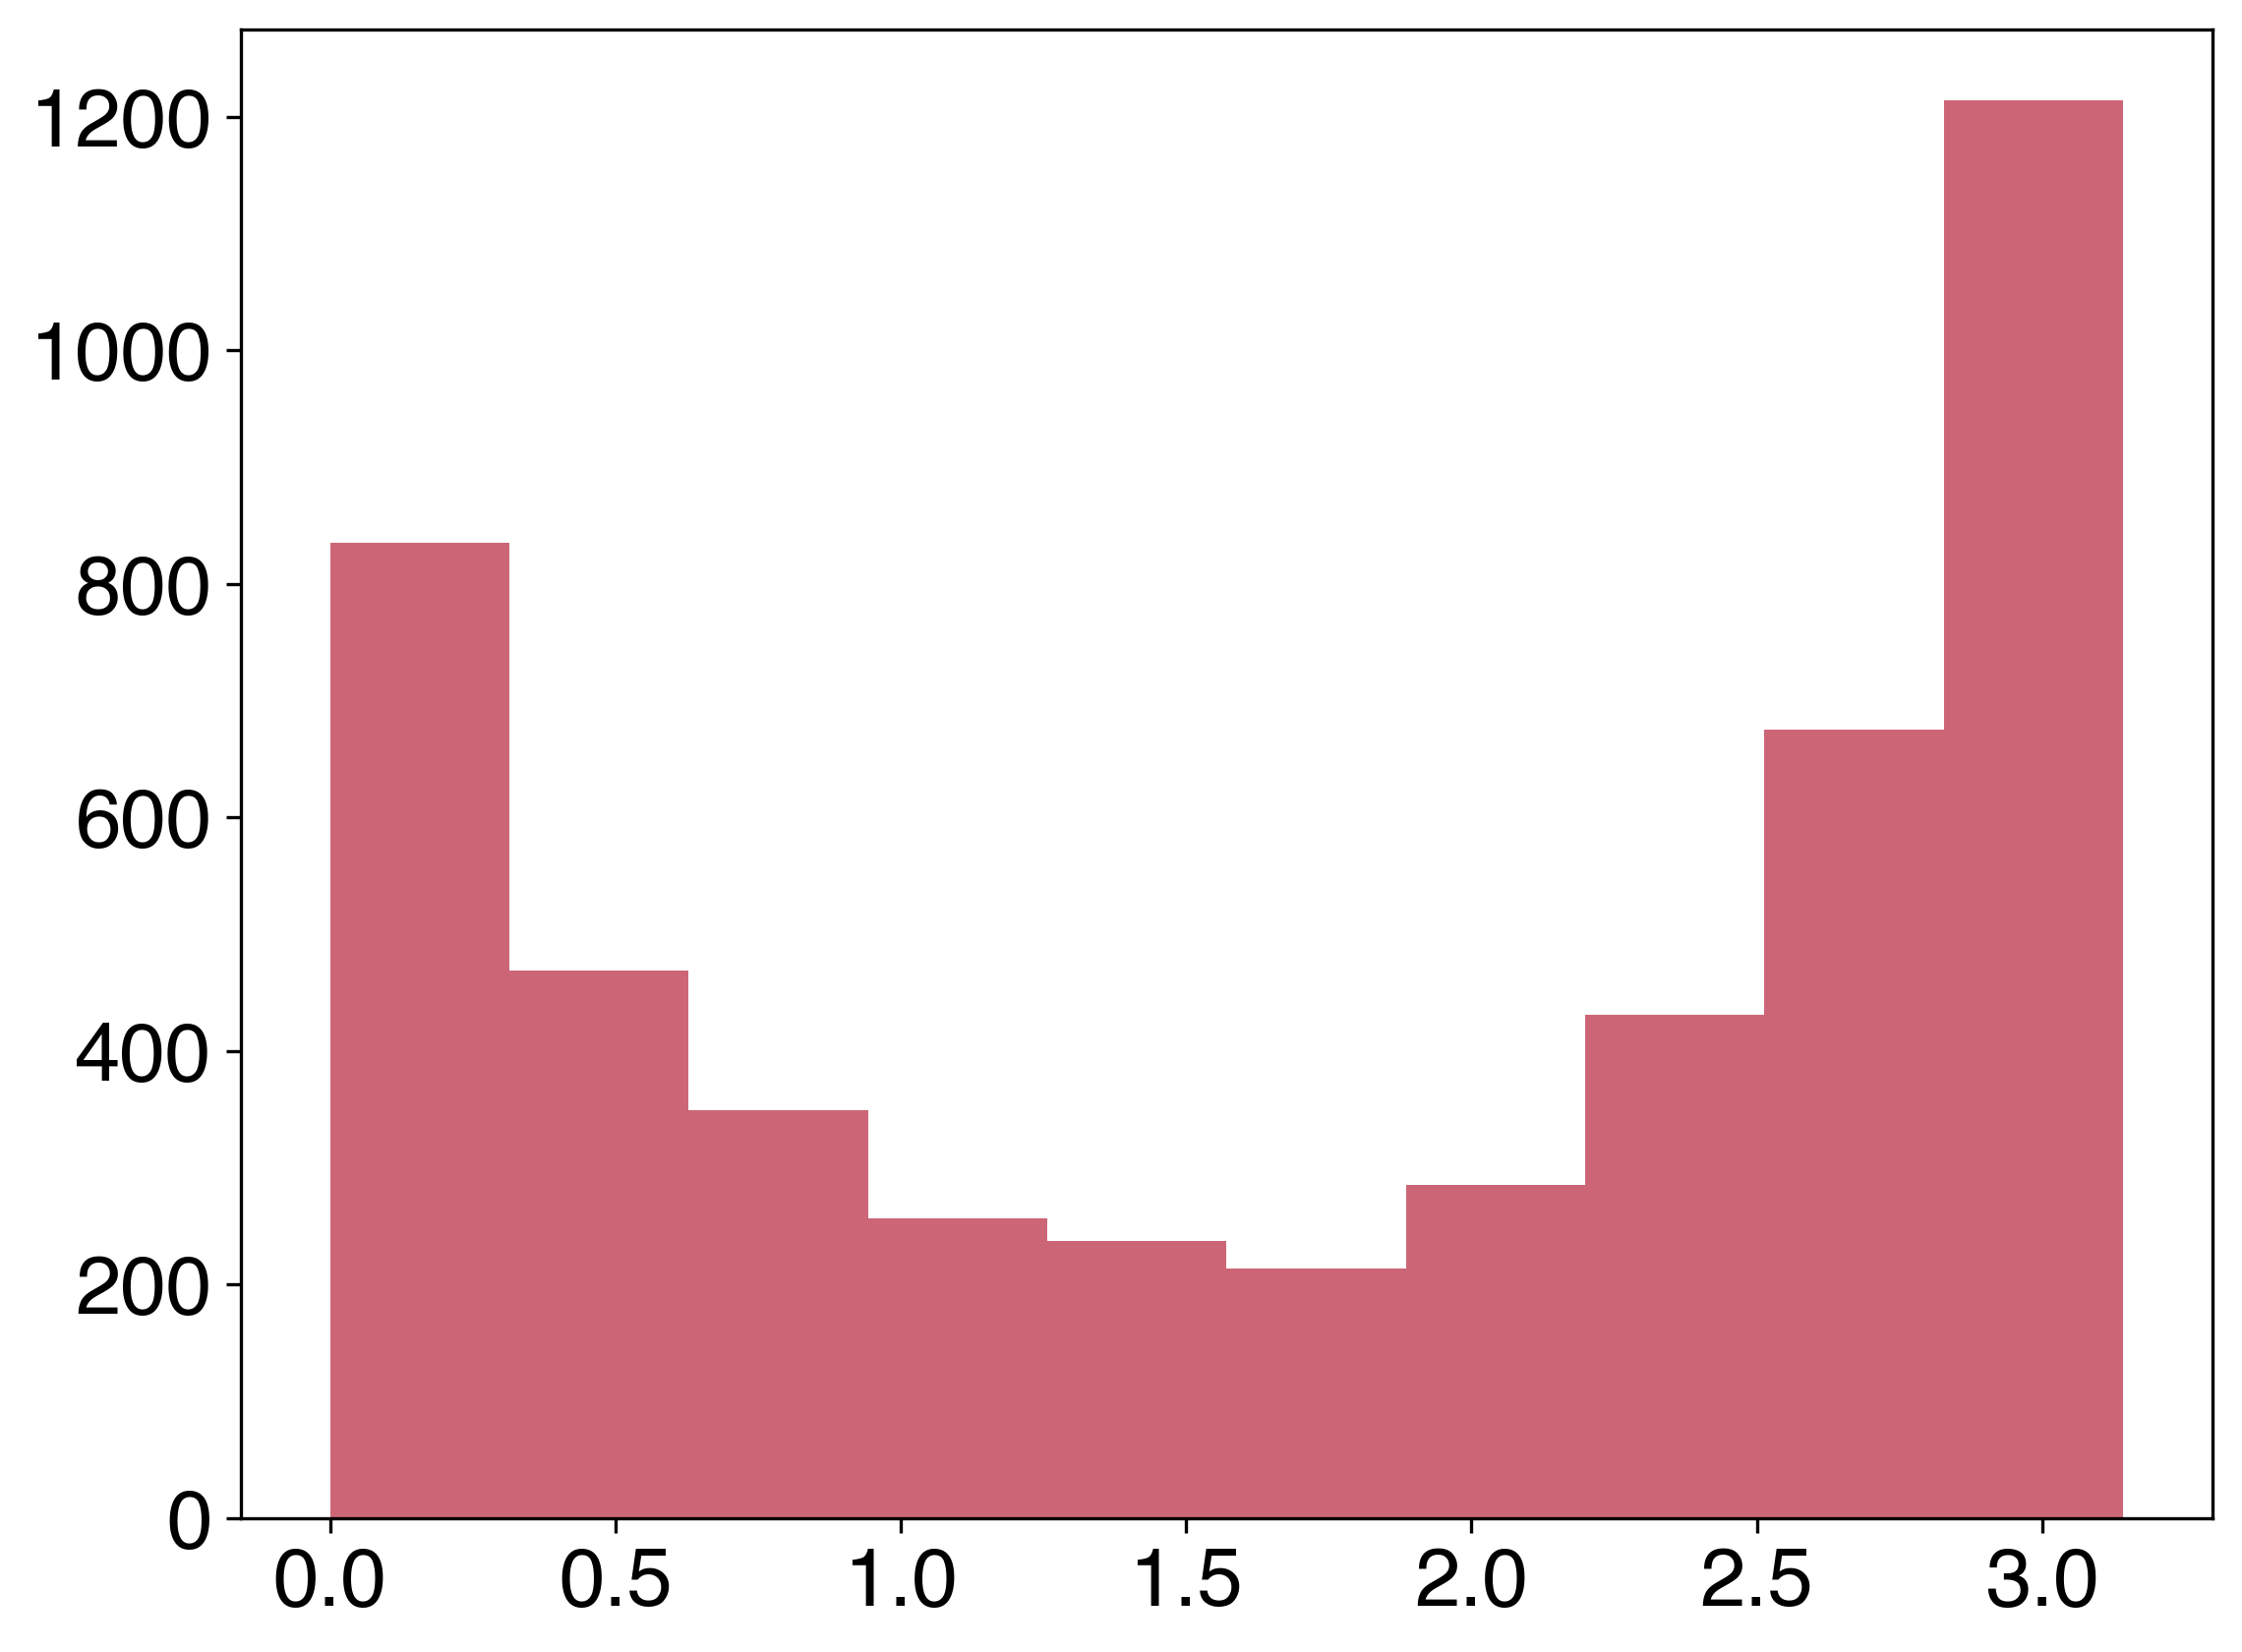

In [28]:
plt.hist(np.abs(fast['omega'].to_numpy()))

In [41]:
def _calculate_msd(pos):
    num_steps = len(pos)
    msd = []
    for tau in range(1, num_steps):
        displacements = pos[tau:] - pos[:-tau]
        squared_displacements = np.mean(displacements**2)
        msd_tau = np.mean(squared_displacements)
        msd.append(msd_tau)
    
    return np.array(msd)

def imsd(df, time_scale = 1, display=True, figsize=(10,8), title='indivisual MSD'):
    msd_df = pd.DataFrame(columns=['particle', 'lag time', 'MSAD'])

    deg2rag = 2*np.pi/360

    if display == True:
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set(ylabel='MSAD $[deg^2]$',
        xlabel='lag time $\Delta t [s]$')
        ax.set_title(title)

    for particle_id, group in df.groupby('TID'):
        data = pd.DataFrame()
        group = group.sort_values(by='PID')  # フレーム順に並べ替え
        alpha = group['α [deg]'].to_numpy()[1:] * deg2rag
        lag_t = time_scale * np.arange(1, alpha.shape[0])
        msd=_calculate_msd(alpha)
        data = pd.DataFrame({'particle':particle_id, 'lag time':lag_t, 'MSAD':msd})

        msd_df=pd.concat([msd_df, data])


        if display == True:
            ax.plot(lag_t, msd, color='black', alpha = 0.2)

    return msd_df

def emsd(imsd_list, display=True, figsize=(10,8), title = 'Ensemble MSAD'):
    emsd=imsd_list.groupby('lag time').mean()['MSAD']
    N = len(imsd_list[imsd_list['lag time']==0].index)
    emsd_err = imsd_list.groupby('lag time').std()['MSAD']/np.sqrt(N)
    
    if display == True:
        times = emsd.index
        fig, ax = plt.subplots(figsize=figsize)
        ax.errorbar(times, emsd, yerr= emsd_err, fmt ='o')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set(ylabel='$\\langle \\Delta r^2 \\rangle$ [\u03bcm$^2$]',
        xlabel='lag time $\Delta t [s]$')
        ax.set_title(title)
        ax.grid('True')

    return emsd, emsd_err

<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:54: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:54: SyntaxWarning: invalid escape sequence '\D'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_20531/3774965690.py:22: SyntaxWarning: invalid escape sequence '\D'
  xlabel='lag time $\Delta t [s]$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_20531/3774965690.py:54: SyntaxWarning: invalid escape sequence '\D'
  xlabel='lag time $\Delta t [s]$')


/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_20531/3774965690.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  msd_df=pd.concat([msd_df, data])
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_20531/3774965690.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  msd_df=pd.concat([msd_df, data])
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_20531/3774965690.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprec

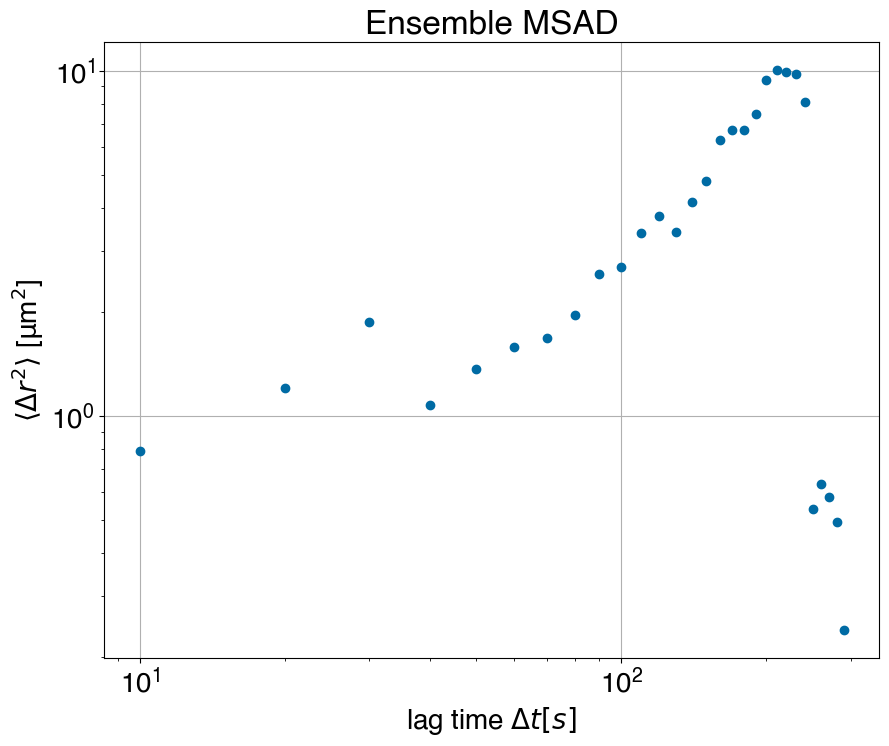

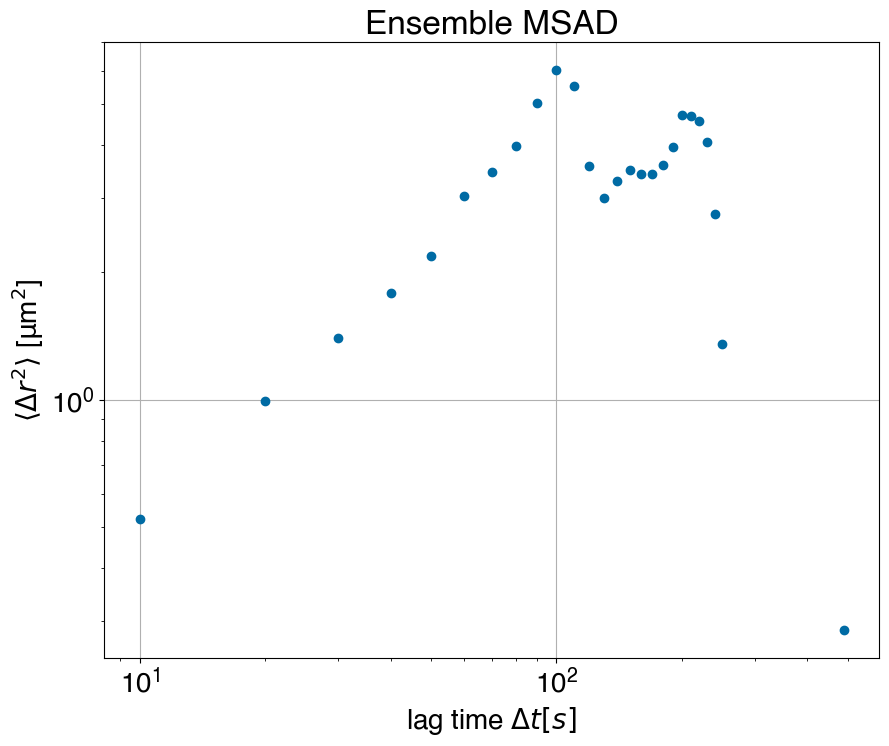

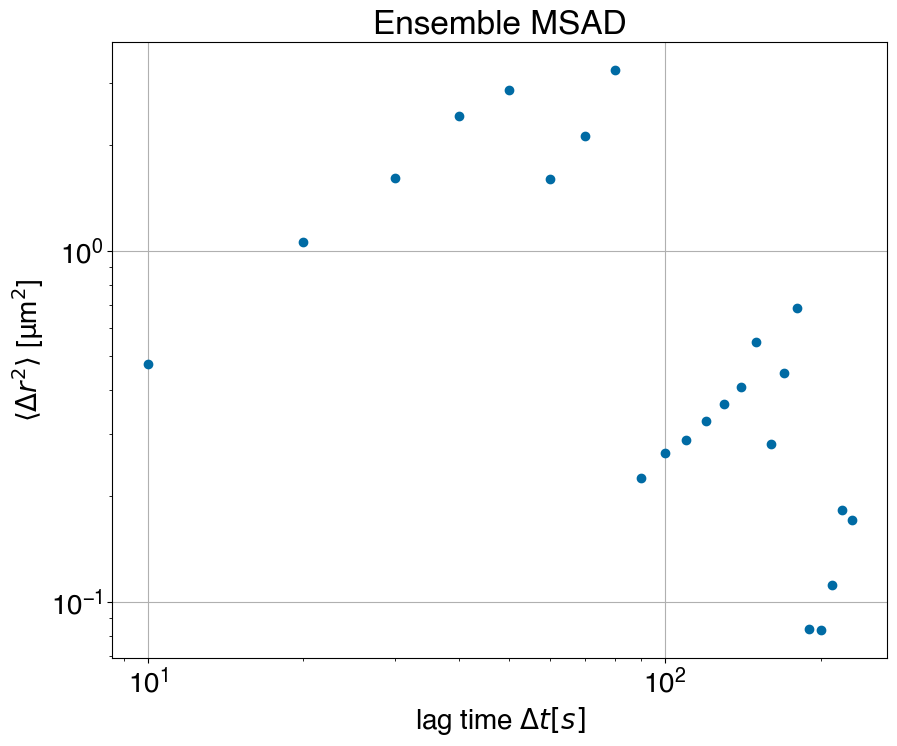

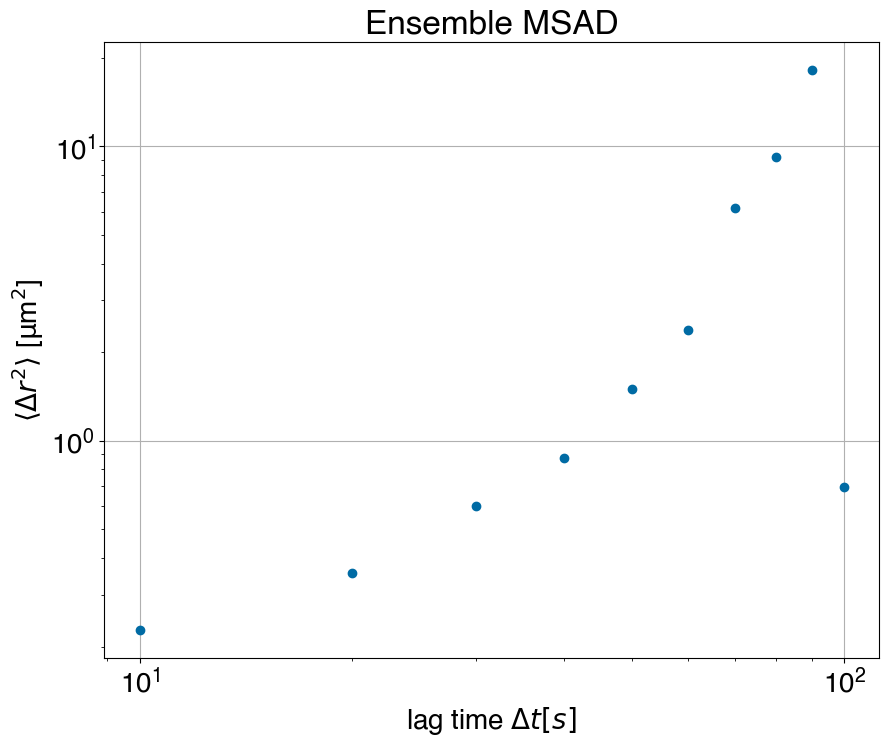

In [55]:
imsd10_list = []

j= 0
for MT in MT10:
    j += 1 
    i = imsd(MT, time_scale=interval, display = False)
    i['particle'] = i['particle']+ j * 100
    imsd10_list.append(i)

imsd10 = pd.concat(imsd10_list)

imsd13_list = []

j=0
for MT in MT13:
    j+=1
    i = imsd(MT, time_scale=interval, display = False)
    i['particle'] = i['particle']+ j * 100
    imsd13_list.append(i)

imsd13 = pd.concat(imsd13_list)

imsd40 = imsd(MT_40, time_scale=interval, display = False)
imsd43 = imsd(MT_43, time_scale=interval, display = False)

emsd10,_ = emsd(imsd10)
emsd13,_ = emsd(imsd13)
emsd40,_ = emsd(imsd40)
emsd43,_ = emsd(imsd43)

<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_20531/3660614522.py:16: SyntaxWarning: invalid escape sequence '\D'
  xlabel='lag time $\Delta$ [s]',


[(8.0, 100.0),
 (0.30000000000000004, 10.0),
 None,
 None,
 Text(0.5, 0, 'lag time $\\Delta$ [s]'),
 Text(0, 0.5, 'MSD $\\langle \\Delta r^2 \\rangle$ $[μm^2]$')]

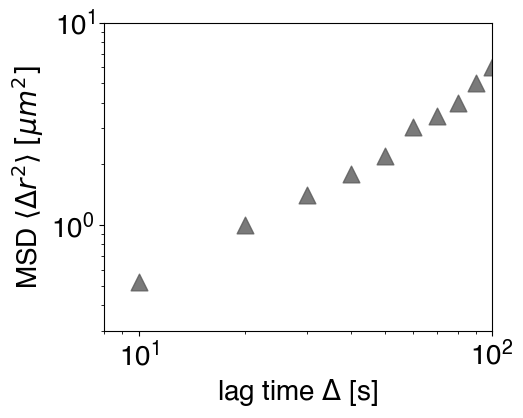

In [70]:
cm = plt.get_cmap('viridis')

plt.rcParams['font.size'] = 20


fig, ax = plt.subplots(figsize = (5, 4))

ax.scatter(emsd13.index, emsd13.to_numpy(), color=colors[3], s = s, alpha = alpha, marker=markers[3])


ax.set(
    xlim=(0.8*1e1, 1e2),
    ylim=(3*1e-1, 1e1),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ $[\u03bcm^2]$'
    )

#fig.savefig(f"/Users/sasakinozomu/Documents/analysis/Output/MSD_w_sim_focus_legend_JPS.pdf", bbox_inches = 'tight')
#fig.savefig(f"/Users/sasakinozomu/Documents/analysis/Output/MSD_w_sim_focus_legend_JPS.png", bbox_inches = 'tight')


In [72]:
def fit(emsd, start, end):
    x = emsd.index[start:end]
    y = emsd.to_numpy()[start:end]
    popt, pcov = curve_fit(fm.ln_pl, np.log10(x), np.log10(y))
    return popt, pcov

start, end = 3, 8

popt01, pcov01 = fit(emsd13, start, end)

print(f"{popt01[0]:.2f}, {popt01[1]:.2f}")

1.20, 0.02


/Users/sasakinozomu/Documents/analysis/script/fit_model.py:8: RuntimeWarning: invalid value encountered in log10
  return k * x + np.log10(a)


lag time
10     0.523959
20     0.995807
30     1.396277
40     1.783852
50     2.191820
60     3.033259
70     3.445905
80     3.981473
90     5.018966
100    6.035179
110    5.527442
120    3.563399
130    3.004345
140    3.287238
150    3.492524
160    3.425888
170    3.417026
180    3.587998
190    3.960804
200    4.721875
210    4.683760
220    4.566365
230    4.071700
240    2.755668
250    1.356022
260         NaN
270         NaN
280         NaN
290         NaN
300         NaN
310         NaN
320         NaN
330         NaN
340         NaN
350         NaN
360         NaN
370         NaN
380         NaN
390         NaN
400         NaN
410         NaN
420         NaN
430         NaN
440         NaN
450         NaN
460         NaN
470         NaN
480         NaN
490    0.286482
Name: MSAD, dtype: float64

In [7]:
import numpy as np
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import fit_model as fm

plt.style.use('my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

interval = 10

def getdf(dir_path, interval=10):
    df_list = []

    file_list = glob.glob(os.path.join(dir_path, "*.csv"))
    for file_path in file_list:
        file = pd.read_csv(file_path)
        df_list.append(file)

    df_concat = pd.concat(df_list, ignore_index=True)

    only_MT = df_concat[df_concat['TID'] == 1]['Δα [deg]'].to_numpy()/interval

    plots = only_MT[~np.isnan(only_MT)]

    return plots

MC00_1 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240827/cargo_before_after_MT1uM_MC00')
MC00_2 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240926/cargo_before_after_MT1uM_MC00')
MC00_3 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240828/cargo_before')
MC00_4 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20241129/cargo_before_after_MT1uM_MC00') 

MC03_1 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240910/cargo_before_after_MT1uM_MC03')
MC03_2 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240910/cargo_before_MT083uM_MC03_1')
MC03_3 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20240926/cargo_before_after_MT1uM_MC03')
MC03_4 = getdf(dir_path='/Volumes/My Passport/Sasaki/MTsingleBeads/20241127/cargo_before_after_MT1uM_MC03')

In [ ]:
MC03 = [MC03_1, MC03_2, MC03_3, MC03_4]
MC03 = np.concatenate(MC03) * (2*np.pi/360)  # deg -> rad


14

mu:0.0819, std: 0.1407 rad


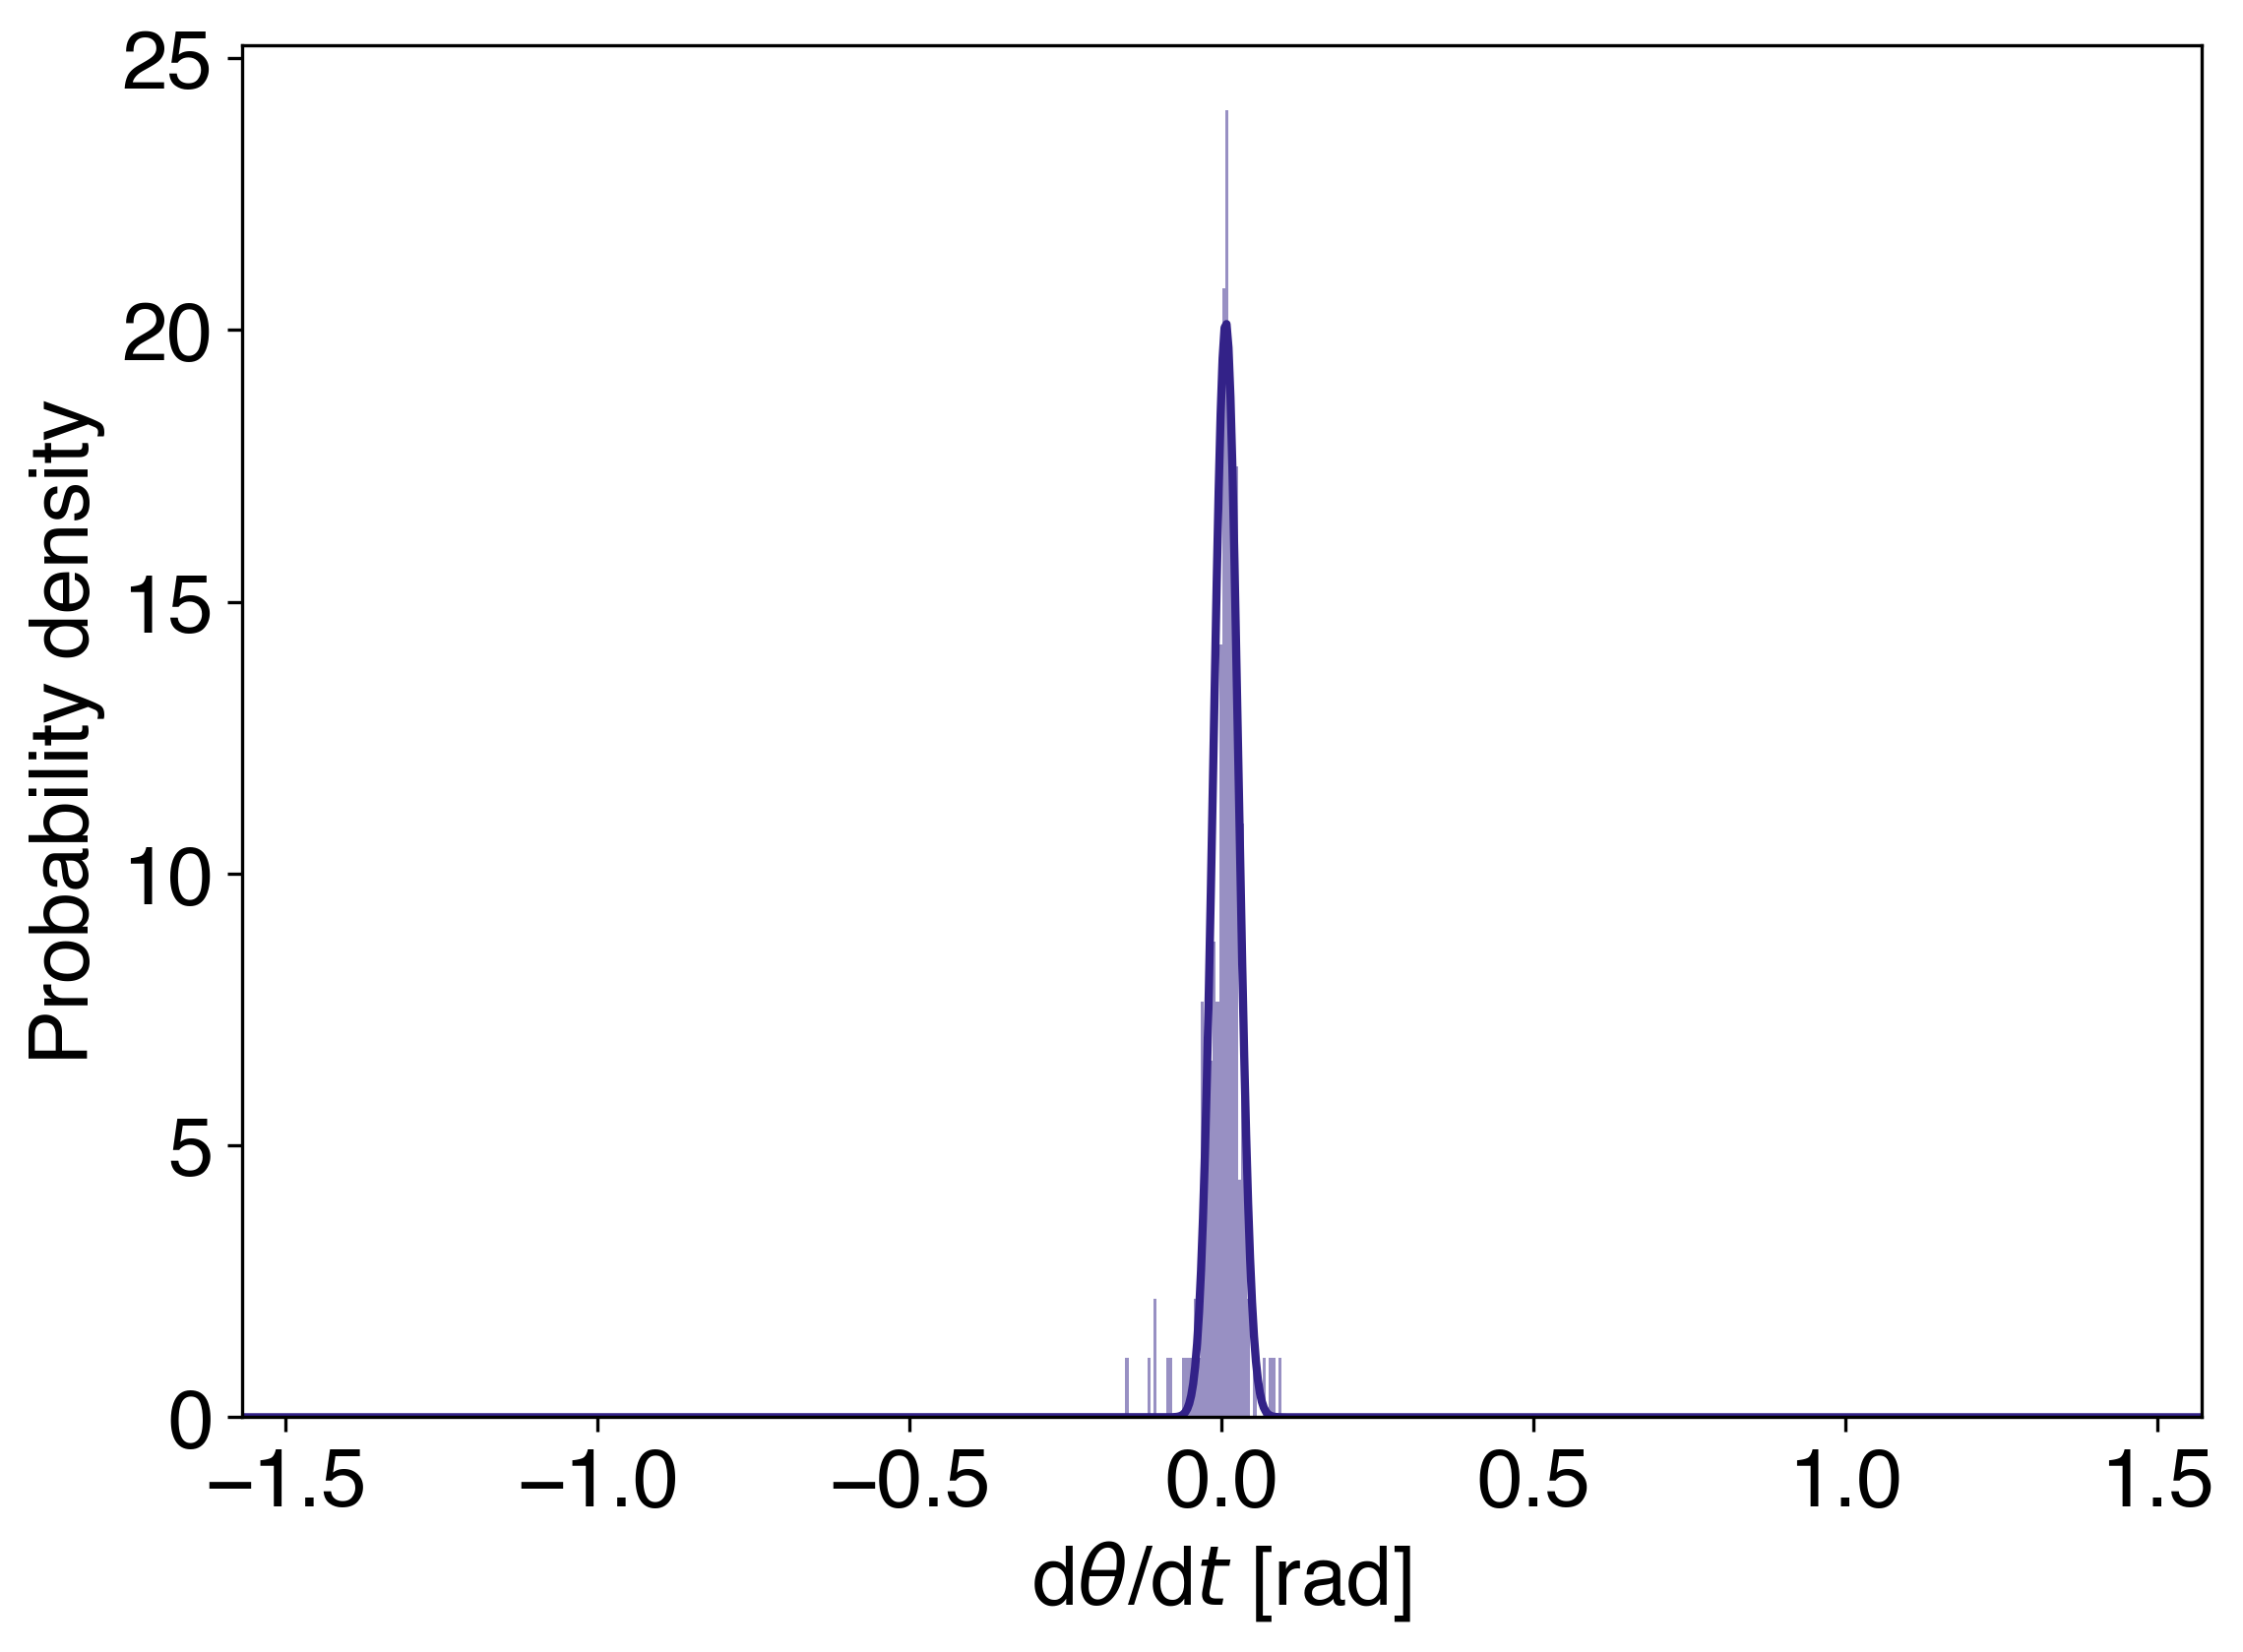

In [19]:
bins = 50

hist, bin_edges = np.histogram(MC03, bins=bins, density=True)

popt, pcov = curve_fit(fm.gaussian, bin_edges[:-1], hist)

fig, ax = plt.subplots()

ax.hist(MC03, bins, density=True, color=style_colors[1], alpha=0.5)
#ax.plot(bin_edges[:-1], hist)

ax.plot(np.linspace(-np.pi/2, np.pi/2, 1000),  fm.gaussian(np.linspace(-np.pi/2, np.pi/2, 1000), *popt) ,color=style_colors[1])

ax.set(xlabel='d$\\theta$/d$t$ [rad]',
    ylabel='Probability density',
    xlim=(-np.pi/2, np.pi/2))


print(f"mu:{np.sqrt(popt[0]):.4f}, std: {np.sqrt(popt[1]):.4f} rad")